In [20]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
# .read_csv will help us to load our data in python DateFrame
data = pd.read_csv("Customer Churn.csv")
# .head function return us top five rows
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
''' .info give us detail about out table how many rows there are 
 how many columns with their name what is datatype of each column 
 it also tell us non-null values count'''
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [23]:
""" Since in data we see total charges is numbers so its datatype must be float or int
    so let check what values are there in totalcharges column that cause change in column dtype
    .to_numeric convert string to number and where data is string coerce convert it to null and than
    we will get data where values is null"""
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"],errors="coerce")
print(data["TotalCharges"].isnull().sum())
print(data[data["TotalCharges"].isnull()])

# Since his tenure is null so we replace total charges with 0
data["TotalCharges"] = data["TotalCharges"].fillna(0)

11
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  .

In [24]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [25]:
# data.isnull().sum().sum() it tells how much data are null in our table
data.isnull().sum().sum()

np.int64(0)

In [26]:
# duplicates function tells how many rows are duplicate in our table
data.duplicated().sum()

np.int64(0)

In [27]:
# .describe function give us statistical analysis about our data that has type integer,float e.t.c
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [28]:
# In SeniorCitizen column there are only two values 0 and 1 where 1 denote SeniorCitizen so lets fix it with yes and no
def convert(value):
    if value == 1:
        return "Yes"
    else:
        return "No"
data["SeniorCitizen"] = data["SeniorCitizen"].apply(convert)

In [29]:
data.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


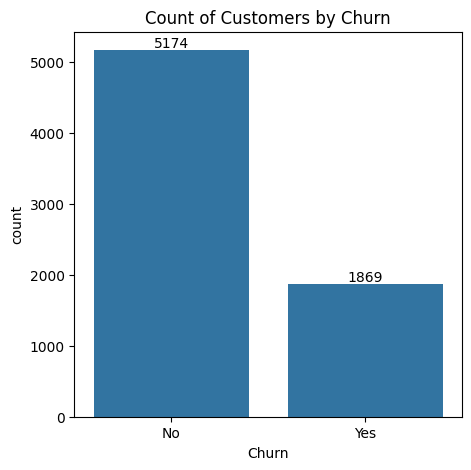

In [30]:
plt.figure(figsize=(5,5))
ax = sns.countplot(x = "Churn" , data=data)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")
plt.show()

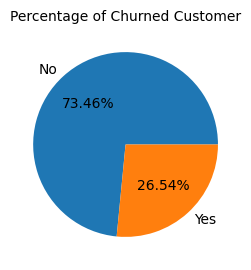

In [31]:
plt.figure(figsize=(3,3))
group = data.groupby("Churn").agg({"Churn":"count"})
plt.pie(group["Churn"],labels=group.index,autopct="%1.2f%%")
plt.title("Percentage of Churned Customer",fontsize=10)
plt.show()

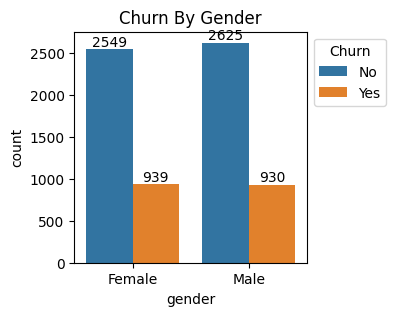

In [32]:
plt.figure(figsize=(3,3))

ax = sns.countplot(x="gender", data=data, hue="Churn")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Churn By Gender")
plt.legend(title="Churn", bbox_to_anchor=(1,1))

plt.show()

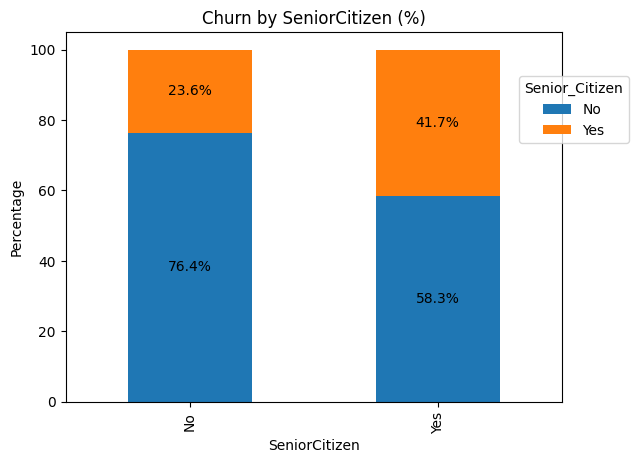

In [33]:
ct = pd.crosstab(data['SeniorCitizen'], data['Churn'], normalize='index') * 100

ax = ct.plot(kind='bar', stacked=True)

plt.title("Churn by SeniorCitizen (%)")
plt.xlabel("SeniorCitizen")
plt.ylabel("Percentage")
plt.legend(title = "Senior_Citizen" ,bbox_to_anchor = (0.9,0.9))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.show()

#### A lot of senior people churn and that can be a big danger for company

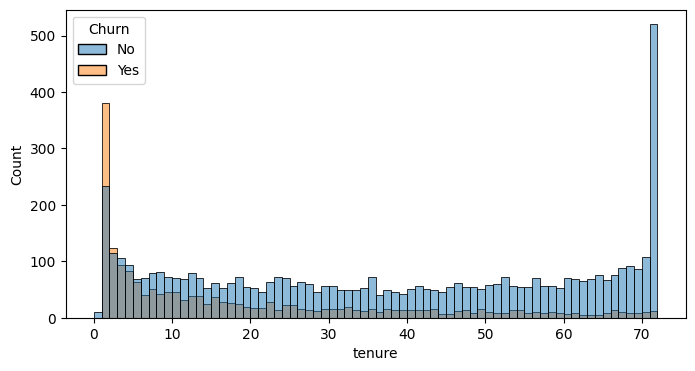

In [34]:
plt.figure(figsize=(8,4))
sns.histplot(data=data,x="tenure",bins=72,hue="Churn")
plt.show()

##### People who used our service for long time stay and people how joined new left

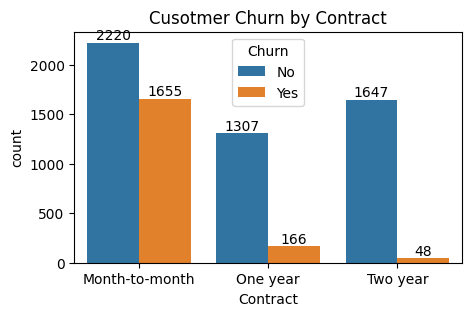

In [35]:
plt.figure(figsize=(5,3))
ax = sns.countplot(data=data,x="Contract",hue="Churn")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Cusotmer Churn by Contract")
plt.show()

##### People who have contract according to month are more likely to churn

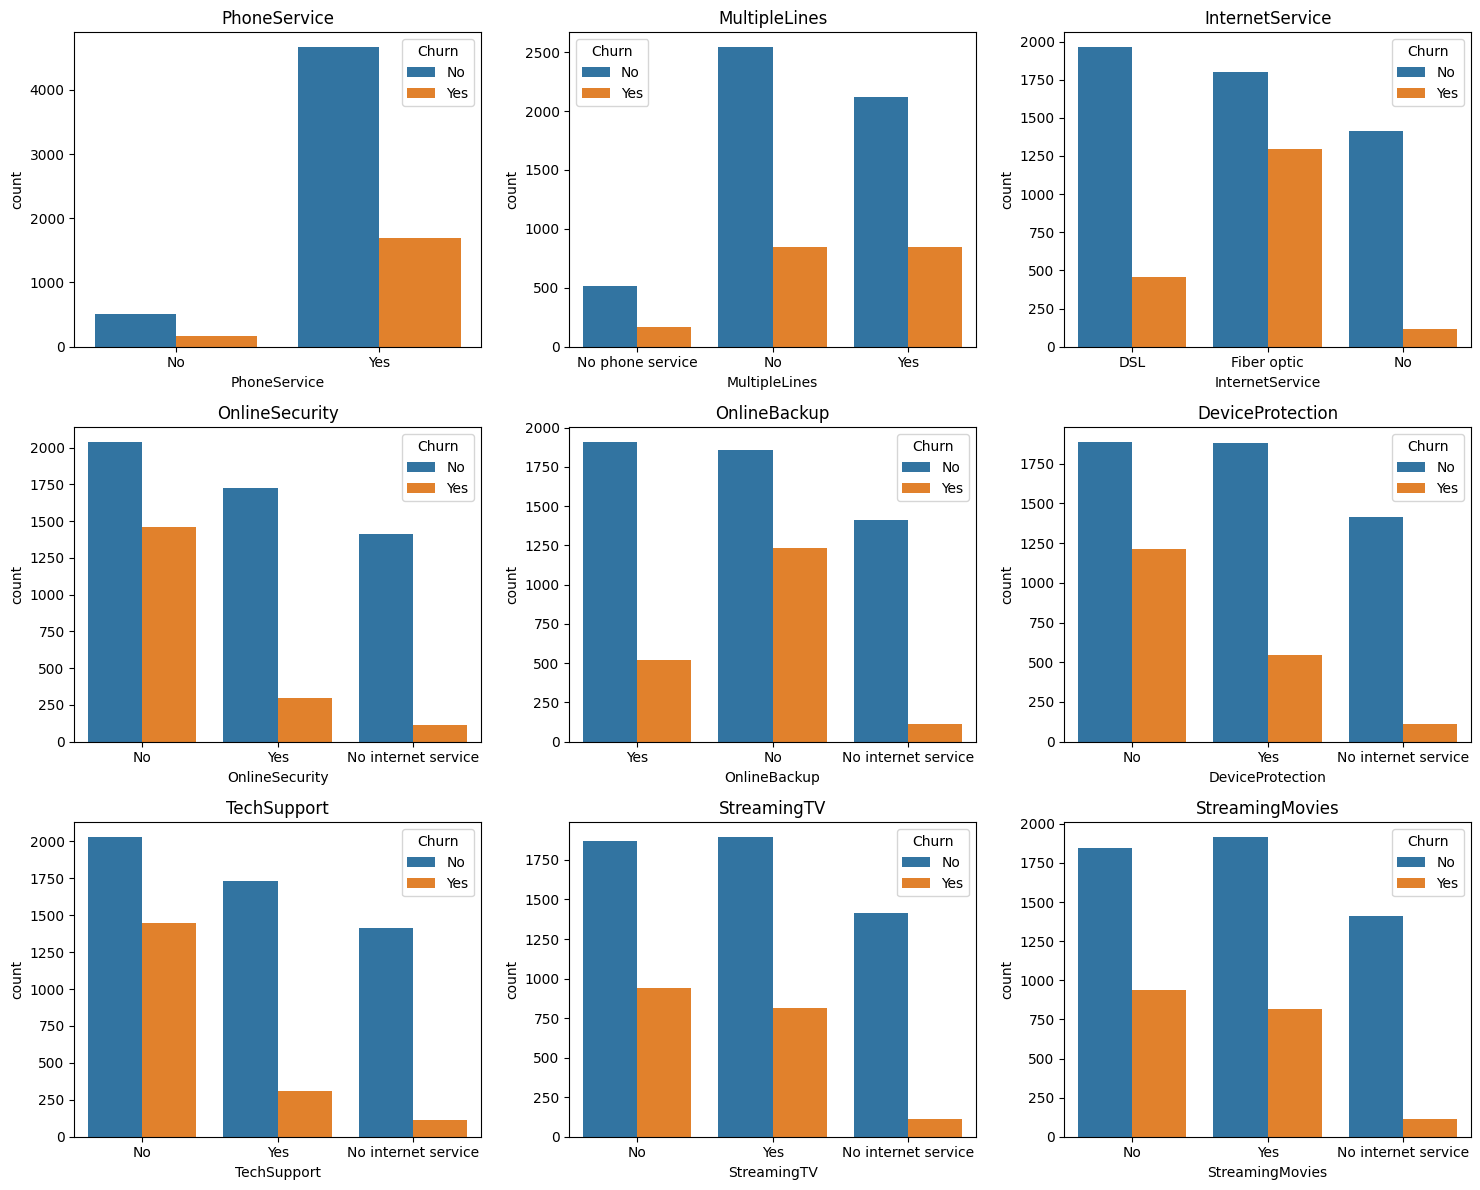

In [36]:
cols = ['PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

plt.figure(figsize=(15, 12))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=col, data=data, hue="Churn")
    plt.title(col)

plt.tight_layout()
plt.show()

Customers using fiber optic internet show the highest churn, while those with no internet churn the least.
Lack of online security and tech support strongly increases churn rates.
Users without backup and device protection are more likely to leave.
Overall, customers with more services and support features tend to stay longer, reducing chu

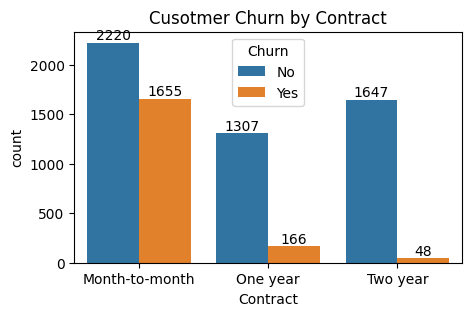

In [37]:
plt.figure(figsize=(5,3))
ax = sns.countplot(data=data,x="Contract",hue="Churn")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Cusotmer Churn by Contract")
plt.show()

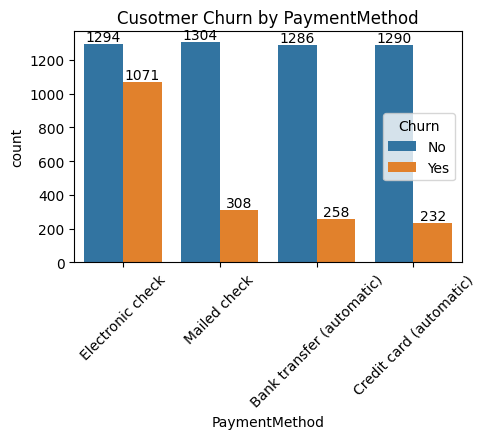

In [38]:
plt.figure(figsize=(5,3))
ax = sns.countplot(data=data,x="PaymentMethod",hue="Churn")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Cusotmer Churn by PaymentMethod")
plt.xticks(rotation=45)
plt.show()

Customer is more likely to churn how is using electronic check method